In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

In [2]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=";")

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
print('missing values: ',df.isnull().sum().sum())
print('duplicate values: ',df.duplicated().sum())

missing values:  0
duplicate values:  0


In [7]:
print(df["y"].value_counts())

print("\nPercentages:")
print(df["y"].value_counts(normalize=True) * 100)

y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [8]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']

y:
['no' 'yes']


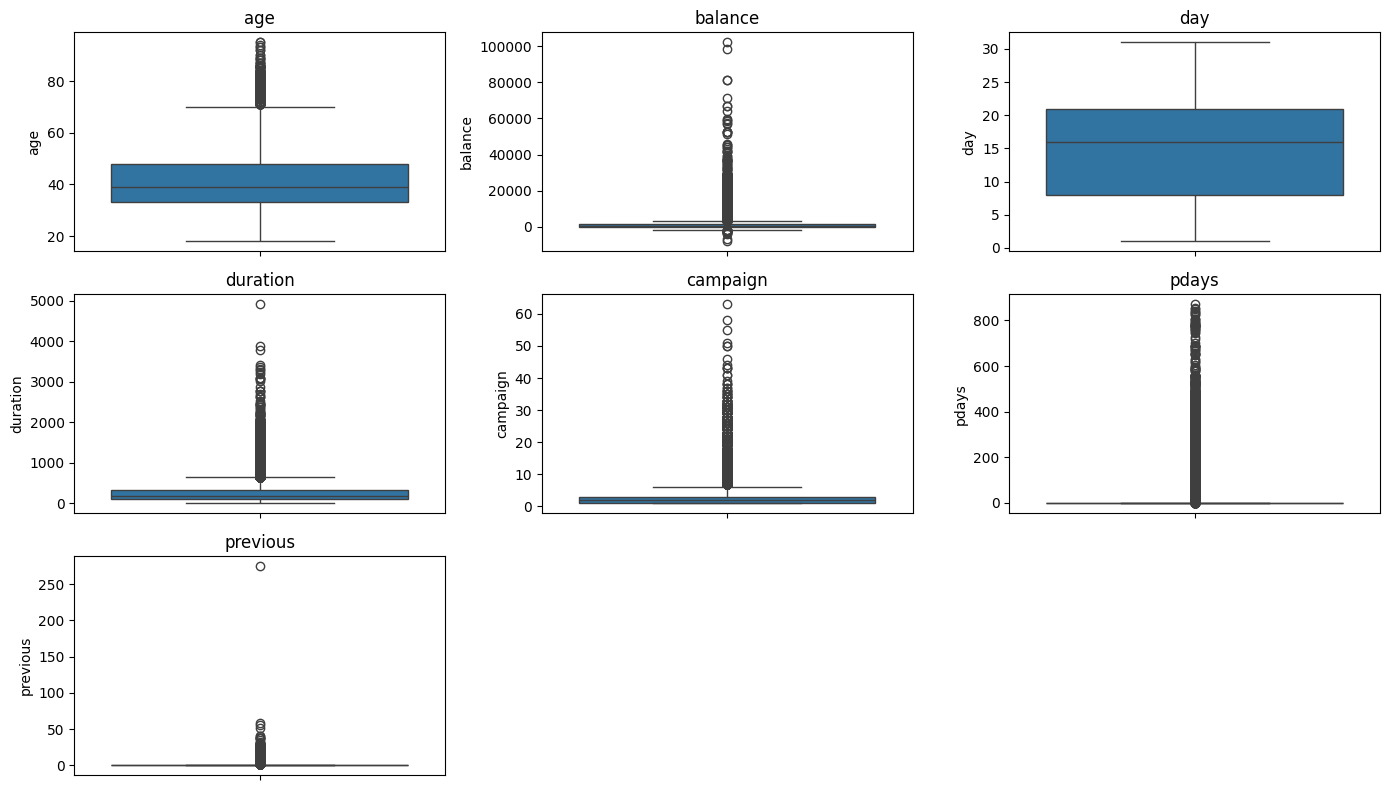

In [9]:
numeric_cols = df.select_dtypes(include="int64").columns

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64


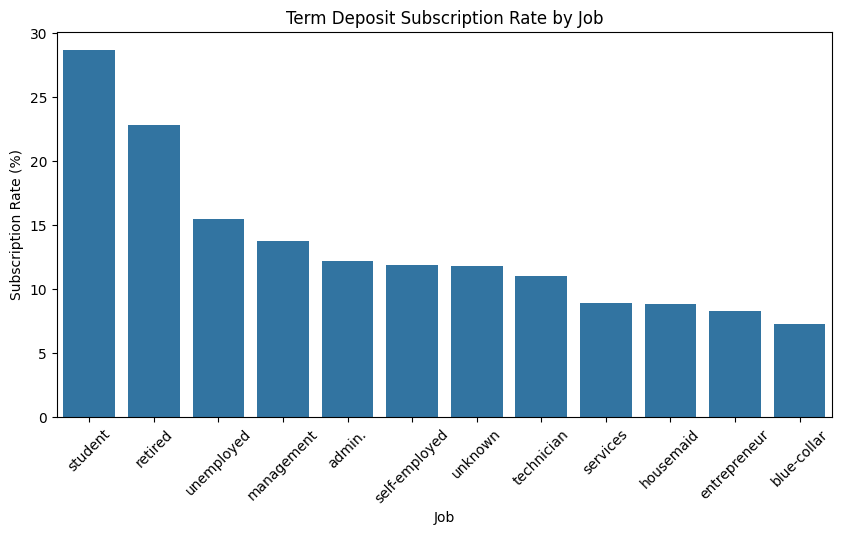

In [10]:
job_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_rate)

plt.figure(figsize=(10, 5))
sns.barplot(x=job_rate.index, y=job_rate.values)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)

plt.show()

education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478
Name: y, dtype: float64


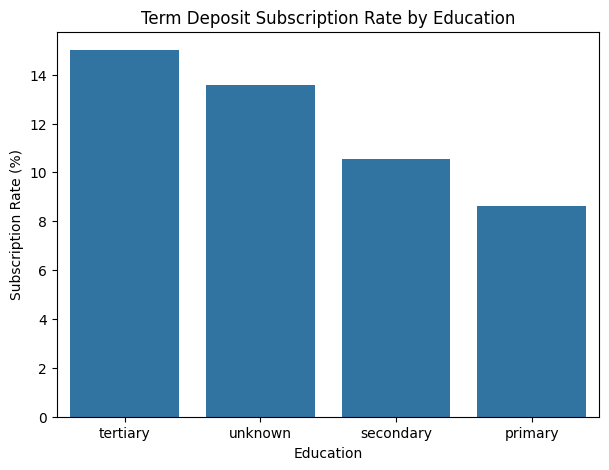

In [11]:
education_rate = (
    df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(education_rate)

plt.figure(figsize=(7, 5))
sns.barplot(x=education_rate.index, y=education_rate.values)

plt.title("Term Deposit Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")

plt.show()

housing
no     16.702355
yes     7.699960
Name: y, dtype: float64


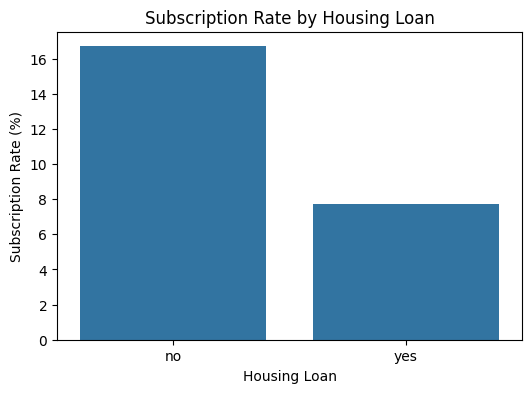

In [12]:
housing_rate = (
    df.groupby("housing")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

print(housing_rate)

plt.figure(figsize=(6, 4))
sns.barplot(x=housing_rate.index, y=housing_rate.values)

plt.title("Subscription Rate by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")

plt.show()

poutcome
success    64.725347
other      16.684783
failure    12.609671
unknown     9.161503
Name: y, dtype: float64


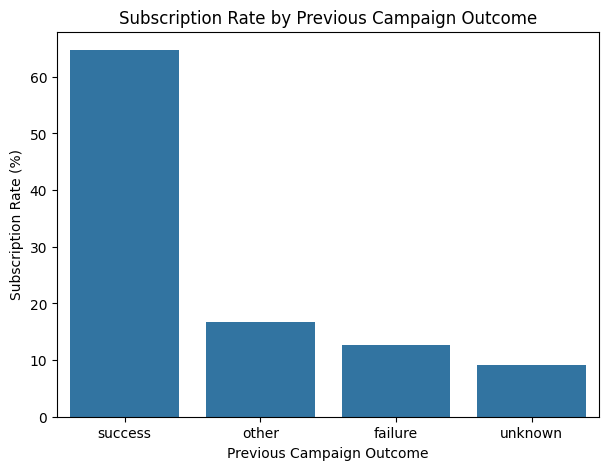

In [13]:
poutcome_rate = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(poutcome_rate)

plt.figure(figsize=(7, 5))
sns.barplot(x=poutcome_rate.index, y=poutcome_rate.values)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.show()

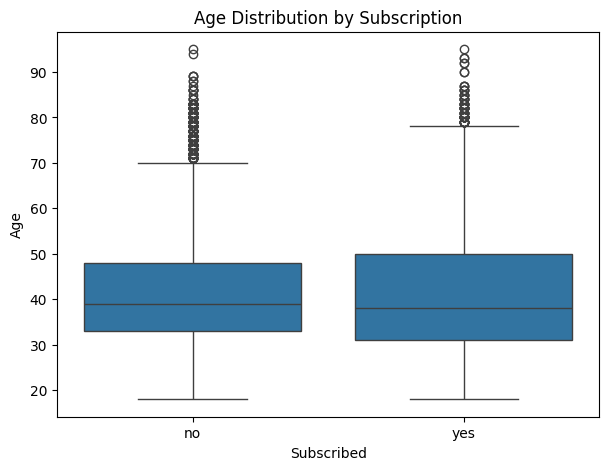

In [14]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="y", y="age")

plt.title("Age Distribution by Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Age")

plt.show()

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(num_cols)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


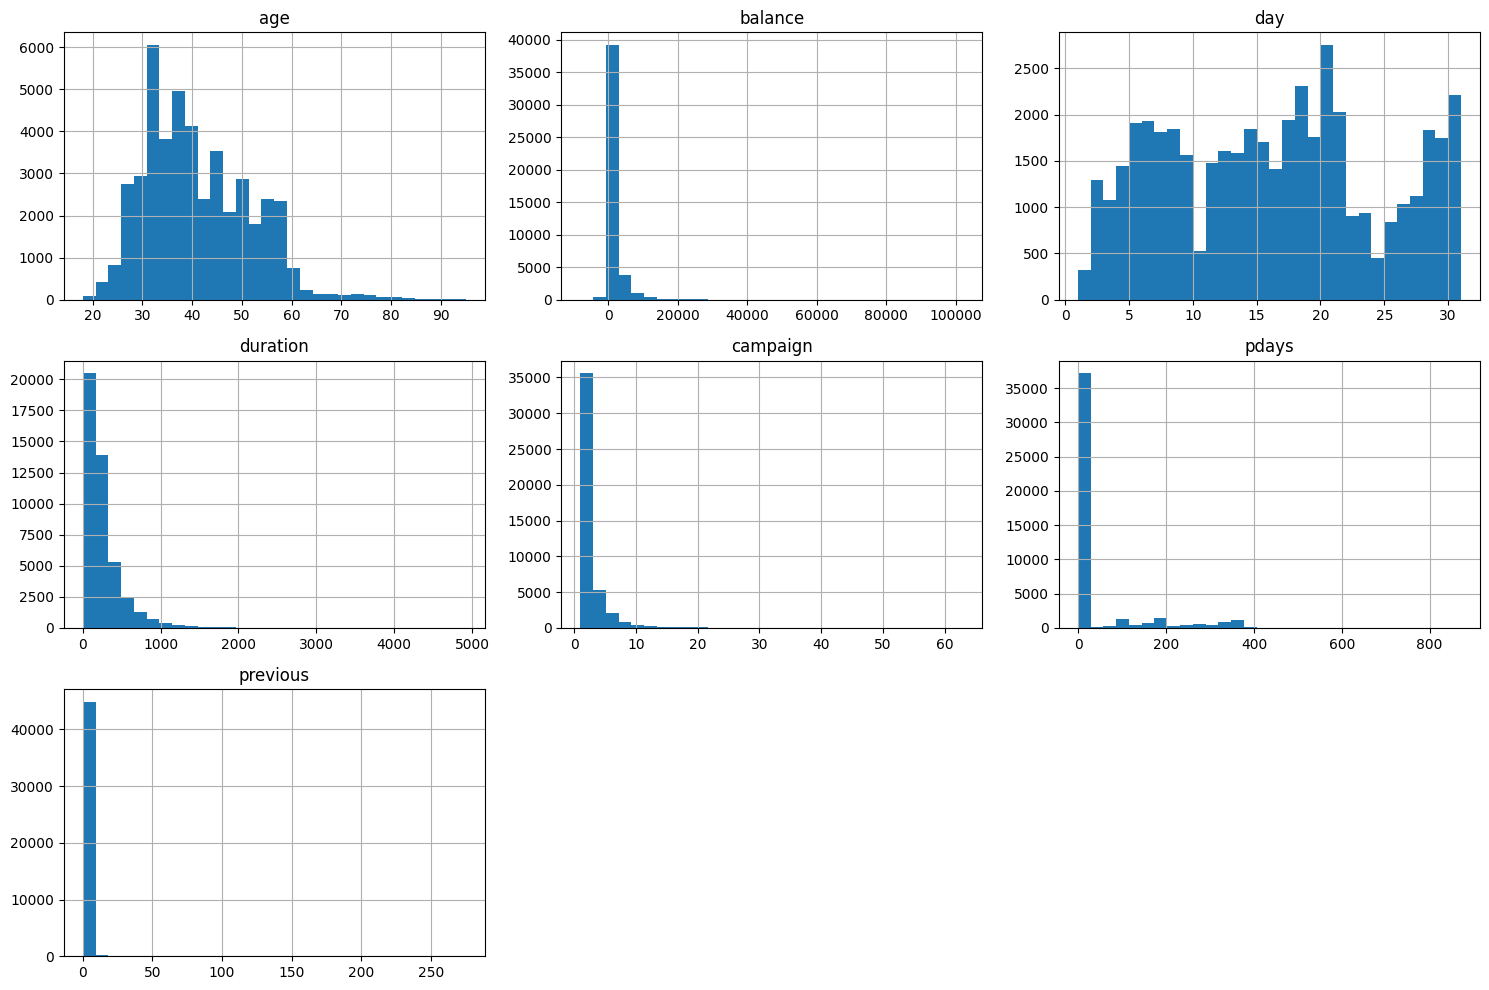

In [16]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

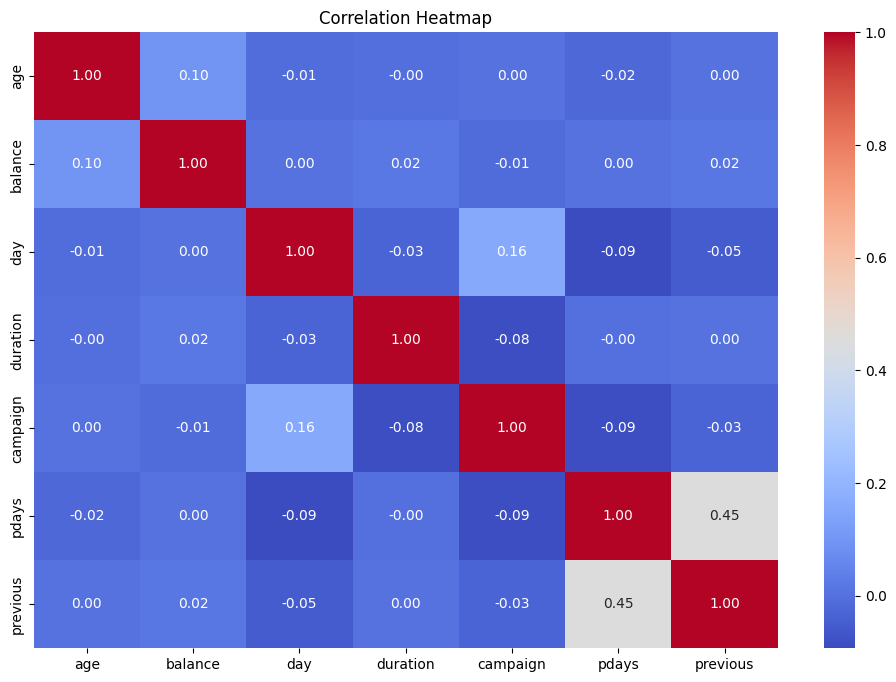

In [17]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
X = df.drop(columns=["y", "duration"])
y=df['y']

In [19]:
print('x shape: ',X.shape)
print('y shape: ',y.shape)

x shape:  (45211, 15)
y shape:  (45211,)


In [20]:
(X_train, X_test, y_train, y_test) = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [21]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 15)
X_test: (9043, 15)
y_train: (36168,)
y_test: (9043,)


In [22]:
print(X_train.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

numerical_cols = [
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape:", X_test_encoded.shape)

X_train encoded shape: (36168, 41)
X_test encoded shape: (9043, 41)


#LogisticRegression:

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

log_model.fit(X_train_encoded, y_train)

y_pred_log = log_model.predict(X_test_encoded)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_log, pos_label="yes"))
print("F1-score:", f1_score(y_test, y_pred_log, pos_label="yes"))

y_prob_log = log_model.predict_proba(X_test_encoded)[:, 1]

print("ROC-AUC:", roc_auc_score(
    (y_test == "yes").astype(int),
    y_prob_log
))

Accuracy: 0.7552803273250027
Precision: 0.2664779619894865
Recall: 0.6228733459357277
F1-score: 0.37326536391956955
ROC-AUC: 0.772198936332656


##Logistic Regression model achieved a good ROC-AUC of 0.772, with a Recall of 62.29%. However, its Precision (26.65%) and F1-score (37.33%) were relatively low. The high Recall indicates that the model can identify many potential customers, but it also produces a relatively high number of false positives.

#RandomForestClassifier

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label="yes"))
print("F1-score:", f1_score(y_test, y_pred_rf, pos_label="yes"))

y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

print("ROC-AUC:", roc_auc_score(
    (y_test == "yes").astype(int),
    y_prob_rf
))

Accuracy: 0.8952781156695787
Precision: 0.6750788643533123
Recall: 0.20226843100189035
F1-score: 0.31127272727272726
ROC-AUC: 0.7922611276104891


##Random Forest achieved a high accuracy of 89.53% and precision of 67.51%, its recall was only 20.23%. This means that the model correctly identifies positive predictions when it predicts "yes", but it misses many actual positive cases. This is important because the dataset is imbalanced, with only 11.70% of customers belonging to the "yes" class. Therefore, accuracy alone is not sufficient to evaluate the model.

#GradientBoosting:

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

y_pred_gb = gb_model.predict(X_test_encoded)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_gb, pos_label="yes"))
print("F1-score:", f1_score(y_test, y_pred_gb, pos_label="yes"))

y_prob_gb = gb_model.predict_proba(X_test_encoded)[:, 1]

print("ROC-AUC:", roc_auc_score(
    (y_test == "yes").astype(int),
    y_prob_gb
))

Accuracy: 0.8950569501271702
Precision: 0.6687306501547987
Recall: 0.20415879017013233
F1-score: 0.3128167994207096
ROC-AUC: 0.7964308669492538


##Gradient Boosting model achieved an Accuracy of 89.51% and a ROC-AUC of 0.796. Its performance was similar to Random Forest, with a low Recall of 20.42%. Although the model had good overall accuracy, it was not effective enough at identifying the minority class (yes).

#SVC

In [30]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_encoded, y_train)

y_pred_svm = svm_model.predict(X_test_encoded)

In [87]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_svm, pos_label="yes"))
print("F1-score:", f1_score(y_test, y_pred_svm, pos_label="yes"))

y_score_svm = svm_model.decision_function(X_test_encoded)

print("ROC-AUC:", roc_auc_score(
    (y_test == "yes").astype(int),
    y_score_svm
))

Accuracy: 0.7592613070883556
Precision: 0.2702258726899384
Recall: 0.6219281663516069
F1-score: 0.37675350701402804
ROC-AUC: 0.7718766164819907


##Linear SVC achieved an Accuracy of 75.93% and a Recall of 62.19%. Similar to Logistic Regression, its high Recall helped identify many positive cases, but its low Precision (27.02%) resulted in many false positives. Therefore, its overall performance was not sufficient compared with the optimized models.

#Optimized Random Forest:

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_rf,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_encoded, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

In [33]:
print("Best Parameters:")
print(rf_search.best_params_)

print("Best CV ROC-AUC:")
print(rf_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}
Best CV ROC-AUC:
0.7901043455153663


In [34]:
best_rf = rf_search.best_estimator_

y_pred_rf_opt = best_rf.predict(X_test_encoded)
y_prob_rf_opt = best_rf.predict_proba(X_test_encoded)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf_opt))
print("Precision:", precision_score(y_test, y_pred_rf_opt, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_rf_opt, pos_label="yes"))
print("F1-score:", f1_score(y_test, y_pred_rf_opt, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(
    (y_test == "yes").astype(int),
    y_prob_rf_opt
))

Accuracy: 0.872055733716687
Precision: 0.4585079631181894
Recall: 0.5170132325141777
F1-score: 0.48600621945801864
ROC-AUC: 0.802419707083106


##After hyperparameter tuning, the Optimized Random Forest improved the model's ability to identify the minority class. It achieved a Recall of 51.70%, Precision of 45.85%, F1-score of 48.60%, and ROC-AUC of 0.802. Although its Accuracy (87.21%) was lower than the original Random Forest, the improvement in Recall and F1-score makes it more suitable for this imbalanced classification problem.

#Optimized Gradient Boosting

In [35]:
gb = GradientBoostingClassifier(
    random_state=42
)

param_grid_gb = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid_gb,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train_encoded, y_train)

RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200]},
                   random_state=42, scoring='roc_auc')

In [36]:
print("Best Parameters:")
print(gb_search.best_params_)

print("Best CV ROC-AUC:")
print(gb_search.best_score_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}
Best CV ROC-AUC:
0.7943311630898107


In [37]:
best_gb = gb_search.best_estimator_

y_pred_gb_opt = best_gb.predict(X_test_encoded)
y_prob_gb_opt = best_gb.predict_proba(X_test_encoded)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_gb_opt))
print("Precision:", precision_score(y_test, y_pred_gb_opt, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_gb_opt, pos_label="yes"))
print("F1-score:", f1_score(y_test, y_pred_gb_opt, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(
    (y_test == "yes").astype(int),
    y_prob_gb_opt
))

Accuracy: 0.8961627778392126
Precision: 0.6380510440835266
Recall: 0.2599243856332703
F1-score: 0.36937541974479515
ROC-AUC: 0.803481066224123


##Optimized Gradient Boosting achieved the highest ROC-AUC of 0.803 and a high Accuracy of 89.62%. However, its Recall (25.99%) and F1-score (36.94%) were considerably lower than those of the Optimized Random Forest. Therefore, the slightly higher ROC-AUC did not translate into better performance for identifying positive customers.

In [38]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(15))

                     Feature  Importance
36              num__balance    0.138586
35                  num__age    0.123938
37                  num__day    0.108725
33     cat__poutcome_success    0.068813
20      cat__contact_unknown    0.062284
38             num__campaign    0.059954
39                num__pdays    0.052527
17          cat__housing_yes    0.044205
40             num__previous    0.028844
28            cat__month_may    0.020760
34     cat__poutcome_unknown    0.018889
11      cat__marital_married    0.018314
18             cat__loan_yes    0.017044
21            cat__month_aug    0.015390
13  cat__education_secondary    0.014701


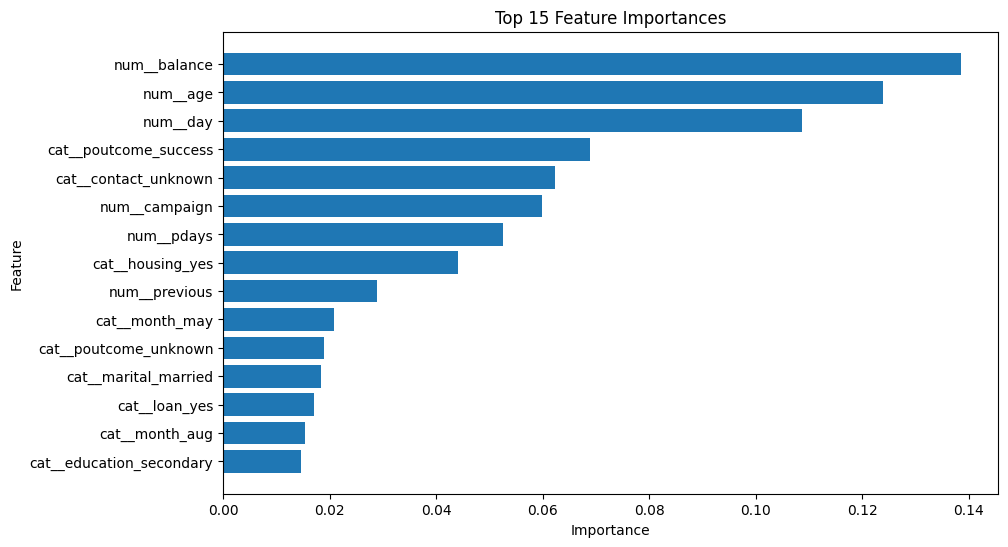

In [39]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.show()

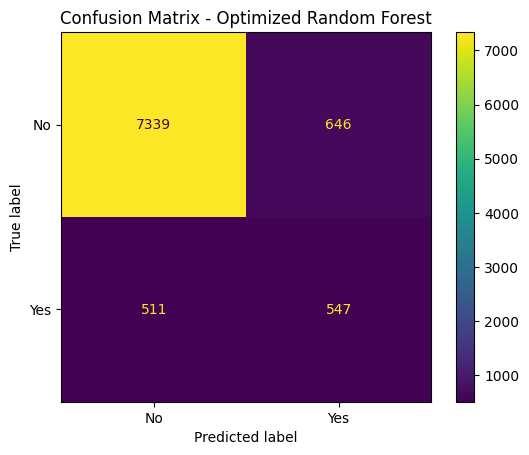

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf_opt, labels=["no", "yes"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Optimized Random Forest")
plt.show()

In [41]:
print(classification_report(y_test, y_pred_rf_opt))

              precision    recall  f1-score   support

          no       0.93      0.92      0.93      7985
         yes       0.46      0.52      0.49      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.72      0.71      9043
weighted avg       0.88      0.87      0.88      9043



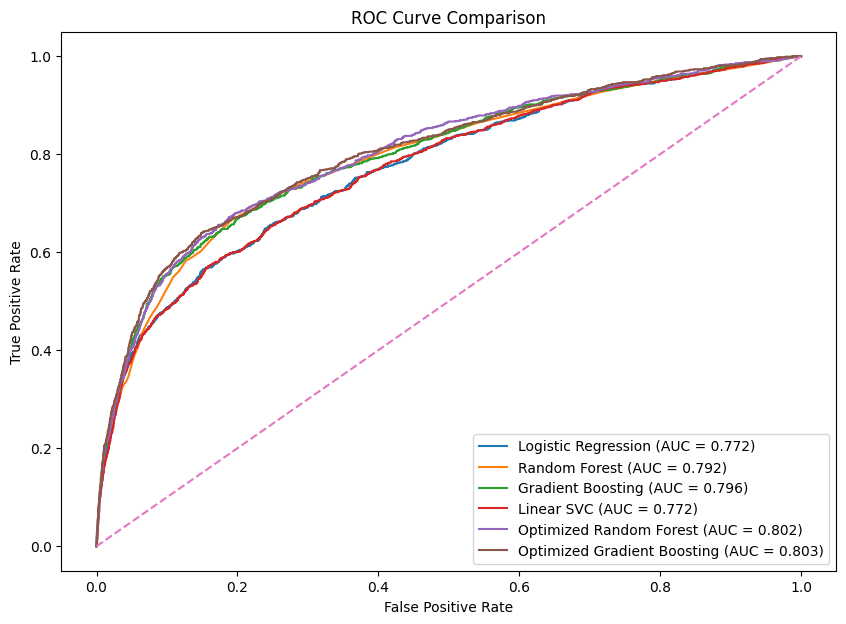

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_test_binary = (y_test == "yes").astype(int)

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(
    y_test_binary,
    y_prob_log
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_binary,
    y_prob_rf
)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(
    y_test_binary,
    y_prob_gb
)
# SVC
fpr_svm, tpr_svm, _ = roc_curve(
    y_test_binary,
    y_score_svm
)
# Optimized Random Forest
fpr_rf_opt, tpr_rf_opt, _ = roc_curve(
    y_test_binary,
    y_prob_rf_opt
)

# Optimized Gradient Boosting
fpr_gb_opt, tpr_gb_opt, _ = roc_curve(
    y_test_binary,
    y_prob_gb_opt
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_log, tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test_binary, y_prob_log):.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test_binary, y_prob_rf):.3f})"
)

plt.plot(
    fpr_gb, tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test_binary, y_prob_gb):.3f})"
)
plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"Linear SVC (AUC = {roc_auc_score(y_test_binary, y_score_svm):.3f})"
)

plt.plot(
    fpr_rf_opt, tpr_rf_opt,
    label=f"Optimized Random Forest (AUC = {roc_auc_score(y_test_binary, y_prob_rf_opt):.3f})"
)

plt.plot(
    fpr_gb_opt, tpr_gb_opt,
    label=f"Optimized Gradient Boosting (AUC = {roc_auc_score(y_test_binary, y_prob_gb_opt):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

##Final Model Selection Note:
The Optimized Random Forest was selected as the final model. Although the Optimized Gradient Boosting achieved a slightly higher ROC-AUC (0.803 vs. 0.802), the difference was minimal. The Optimized Random Forest achieved a substantially higher Recall (51.70%) and F1-score (48.60%), making it more effective at identifying potential customers from the minority yes class. Therefore, it provides a better balance between Precision and Recall for this imbalanced dataset.

#Additional Experiment

In [89]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

/usr/local/lib/python3.13/dist-packages/tensorflow/python/util/tf_decorator.py:66: RuntimeWarning: coroutine 'Server.serve' was never awaited
  name: value for name, value in zip(


In [90]:
y_train_dl = (y_train == "yes").astype(int)
y_test_dl = (y_test == "yes").astype(int)

In [91]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_dl)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_dl
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5662397845758838), np.int64(1): np.float64(4.27416686362562)}


In [92]:
dl_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [93]:
dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = dl_model.fit(
    X_train_encoded,
    y_train_dl,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4580 - loss: 0.6736 - val_accuracy: 0.3728 - val_loss: 0.7101
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4092 - loss: 0.6774 - val_accuracy: 0.4714 - val_loss: 0.6694
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4833 - loss: 0.6734 - val_accuracy: 0.4014 - val_loss: 0.6847
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4757 - loss: 0.6706 - val_accuracy: 0.5010 - val_loss: 0.6581
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4656 - loss: 0.6682 - val_accuracy: 0.4473 - val_loss: 0.6649
Epoch 6/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4723 - loss: 0.6680 - val_accuracy: 0.5355 - val_loss: 0.6553
Epoch 7/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4783 - loss: 0.6705 - val_accuracy: 0.3978 - val_loss: 0.7108
Epoch 8/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4768 - loss: 0.6643 - val_accuracy: 0.

In [97]:
y_prob_dl = dl_model.predict(X_test_encoded).ravel()

y_pred_dl = (y_prob_dl >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test_dl, y_pred_dl))
print("Precision:", precision_score(y_test_dl, y_pred_dl))
print("Recall:", recall_score(y_test_dl, y_pred_dl))
print("F1-score:", f1_score(y_test_dl, y_pred_dl))
print("ROC-AUC:", roc_auc_score(y_test_dl, y_prob_dl))

283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Accuracy: 0.5346676987725313
Precision: 0.16883936080740117
Recall: 0.7589792060491494
F1-score: 0.2762297901616787
ROC-AUC: 0.6539171982438716


##As an additional experiment, a simple Neural Network (MLP) was trained using class weights to handle the imbalanced target classes. The model achieved a high Recall of 75.90%, indicating that it identified many of the positive cases. However, its Precision (16.88%), F1-score (27.62%), and ROC-AUC (0.654) were relatively low. Overall, the MLP did not outperform the traditional machine learning models, particularly the Optimized Random Forest, which achieved a better balance between Precision and Recall.